# lock maintenance prioritization — u.s. inland waterway system
**team a02:** arend colle, sourav dhar, vivek sriram  
**course:** operations and supply chain analytics  
**data:** usace lock stoppages (2021–2023), usda gtr barge rates & volumes

## 0. setup

In [1]:
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

projectDir = Path.cwd()
stoppageDir = projectDir / 'stoppages'
stoppageDir.mkdir(parents=True, exist_ok=True)
figDir = projectDir / 'figures'
figDir.mkdir(parents=True, exist_ok=True)

# pastel palette — color highlights key data, black for all text/labels/gridlines
PBLUE   = '#a8c8e8'   # pastel blue — baseline / normal data
PRED    = '#f4a6a0'   # pastel red — crisis / high-rate / top priority
PGREEN  = '#a8d8b0'   # pastel green — positive / lower priority
PYELLOW = '#f9e0a0'   # pastel yellow — mid-tier
PGRAY   = '#d8d8d8'   # pastel gray — backgrounds
BLACK   = '#1a1a1a'   # all text, gridlines, annotations
WHITE   = '#ffffff'

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False
plt.rcParams['axes.labelcolor']  = BLACK
plt.rcParams['xtick.color']      = BLACK
plt.rcParams['ytick.color']      = BLACK

print('setup complete')


setup complete


## 1. fetch usace stoppage data
pulls from the usace lpms api in 6-month windows for 2021–2023.  
saves each chunk to `stoppages/` and skips files that already exist.

In [2]:
baseUrl = 'https://ndc.ops.usace.army.mil/ords/lpms/stall_stoppage_json'

dateWindows = [
    ('01012021', '30062021', '2021_1'),
    ('01072021', '31122021', '2021_2'),
    ('01012022', '30062022', '2022_1'),
    ('01072022', '31122022', '2022_2'),
    ('01012023', '30062023', '2023_1'),
    ('01072023', '31122023', '2023_2'),
]

for beginDate, endDate, label in dateWindows:
    outputPath = stoppageDir / f'{label}.json'
    if outputPath.exists():
        print(f'{label}: already exists, skipping')
        continue
    resp = requests.get(baseUrl, params={'begin_date': beginDate, 'end_date': endDate}, timeout=30)
    if resp.status_code == 200:
        data = resp.json()
        with open(outputPath, 'w') as f:
            json.dump(data, f)
        print(f'{label}: {len(data)} records saved')
    else:
        print(f'{label}: failed — status {resp.status_code}')

2021_1: already exists, skipping
2021_2: already exists, skipping
2022_1: already exists, skipping
2022_2: already exists, skipping
2023_1: already exists, skipping
2023_2: already exists, skipping


## 2. load and clean stoppage data

In [3]:
allRecords = []
for f in sorted(stoppageDir.glob('*.json')):
    with open(f) as file:
        allRecords.extend(json.load(file))

rawDf = pd.DataFrame(allRecords).drop_duplicates()
print(f'total raw records: {len(rawDf)}')

total raw records: 24881


In [4]:
# filter to mississippi (MI) and illinois (IL) rivers
stopDf = rawDf[rawDf['riverCode'].isin(['MI', 'IL'])].copy()

def parseDate(s):
    """parse usace date strings, correcting malformed year entries like '0024'"""
    try:
        datePart = s.strip().split(' ')[0]
        parts = datePart.split('/')
        if len(parts) == 3 and int(parts[2]) < 2000:
            parts[2] = str(2000 + int(parts[2][-2:]))
        return pd.to_datetime('/'.join(parts), format='%m/%d/%Y', errors='coerce')
    except:
        return pd.NaT

stopDf['beginDt']     = stopDf['beginStopDate'].apply(parseDate)
stopDf['endDt']       = stopDf['endStopDate'].apply(parseDate)
stopDf['durationHrs'] = (stopDf['endDt'] - stopDf['beginDt']).dt.total_seconds() / 3600
stopDf['year']        = stopDf['beginDt'].dt.year

stopDf = stopDf[
    (stopDf['durationHrs'] > 0) &
    (stopDf['durationHrs'] < 8760) &
    (stopDf['year'].between(2021, 2023))
].copy()

# unscheduled + traffic-stopped = operationally impactful events
unschedDf = stopDf[
    (stopDf['isScheduled'] == 'No') &
    (stopDf['trafficStopped'] == 'Y')
].copy()

# classify causes: infrastructure (addressable by maintenance) vs external
infraReasons = [
    'Repairing lock or lock hardware',
    'Lock hardware or equipment malfunction',
    'Maintaining lock or lock equipment',
]
unschedDf['causeType'] = unschedDf['reasonCode'].apply(
    lambda r: 'infrastructure' if r in infraReasons else 'external'
)

print(f'mi + il records (2021–2023): {len(stopDf)}')
print(f'unscheduled + traffic-stopped: {len(unschedDf)}')
print(f'  infrastructure-caused: {(unschedDf["causeType"]=="infrastructure").sum()}')
print(f'  external: {(unschedDf["causeType"]=="external").sum()}')

mi + il records (2021–2023): 166
unscheduled + traffic-stopped: 84
  infrastructure-caused: 7
  external: 77


## 3. load and clean gtr data

In [5]:
# barge freight rates — table 9, twk sheet (spot/nearby rates, % of tariff)
ratesRaw = pd.read_excel(projectDir / 'GTRFigure10Table9.xlsx', sheet_name='TWK', header=0)
ratesDf = ratesRaw[['DATE', 'ILL', 'ST LOUIS', 'CAR-MEM']].copy()
ratesDf.columns = ['date', 'illRate', 'stlRate', 'memRate']
ratesDf['date'] = pd.to_datetime(ratesDf['date'], errors='coerce')
ratesDf = ratesDf[ratesDf['date'].notna() & (ratesDf['date'] >= '2010-01-01')].copy()
for col in ['illRate', 'stlRate', 'memRate']:
    ratesDf[col] = pd.to_numeric(ratesDf[col], errors='coerce')
ratesDf = ratesDf.dropna(subset=['illRate'])
print(f'rate records: {len(ratesDf)} | {ratesDf["date"].min().date()} to {ratesDf["date"].max().date()}')

rate records: 824 | 2010-01-05 to 2026-04-07


In [ ]:
# grain volumes through locks — table 10, socrata sheet
volsRaw = pd.read_excel(projectDir / 'GTRTable10.xlsx', sheet_name='Socrata_Data', header=0)
volsDf = volsRaw[['Week Ending', 'Total_Lock 27', 'Total_Lock 52', 'Total_Lock 1',
                   'Corn_Lock 27', 'Soybean_Lock 27', 'Wheat_Lock 27']].copy()
volsDf.columns = ['date', 'lock27', 'lock52', 'lock1', 'cornLock27', 'soyLock27', 'wheatLock27']
volsDf['date'] = pd.to_datetime(volsDf['date'], errors='coerce')
volsDf = volsDf[volsDf['date'].notna() & (volsDf['date'] >= '2010-01-01')].copy()
for col in ['lock27', 'lock52', 'lock1', 'cornLock27', 'soyLock27', 'wheatLock27']:
    volsDf[col] = pd.to_numeric(volsDf[col], errors='coerce')

# also load other locks sheet (lock 15, 25, 26) for evidence-based volume weights
otherRaw = pd.read_excel(projectDir / 'GTRTable10.xlsx', sheet_name='Other Locks', header=1)
otherRaw.columns = [str(c).strip() for c in otherRaw.columns]
otherRaw['date'] = pd.to_datetime(otherRaw['Week ending'], errors='coerce')
otherRaw = otherRaw[otherRaw['date'].notna() & (otherRaw['date'] >= '2021-01-01') & (otherRaw['date'] <= '2023-12-31')].copy()
for col in otherRaw.columns:
    if col != 'date':
        otherRaw[col] = pd.to_numeric(otherRaw[col], errors='coerce')

# derive annual avg weekly tonnage per lock from actual data (2021-2023 window)
# used to ground the volume weights rather than manual assignment
lockAvgTons = {
    '27': volsDf[(volsDf['date'] >= '2021-01-01') & (volsDf['date'] <= '2023-12-31')]['lock27'].mean(),
    '52': volsDf[(volsDf['date'] >= '2021-01-01') & (volsDf['date'] <= '2023-12-31')]['lock52'].mean(),
    '01': volsDf[(volsDf['date'] >= '2021-01-01') & (volsDf['date'] <= '2023-12-31')]['lock1'].mean(),
}

# for locks in other sheet, pull if column exists
for lockNum, colKey in [('25', 'Mississippi River Lock 25'), ('26', 'Mississippi River Lock 26'), ('15', 'Mississippi River Lock 15')]:
    matchCols = [c for c in otherRaw.columns if colKey in c and 'Total' in c]
    if matchCols:
        lockAvgTons[lockNum] = otherRaw[matchCols[0]].mean()

print('evidence-based avg weekly grain tonnage by lock (2021–2023):')
for k, v in sorted(lockAvgTons.items()):
    print(f'  lock {k}: {v/1000:.0f}k tons/week')
print(f'\nvolume records: {len(volsDf)} | {volsDf["date"].min().date()} to {volsDf["date"].max().date()}')


In [7]:
# align to week-start monday and merge
ratesDf['weekStart'] = ratesDf['date'] - pd.to_timedelta(ratesDf['date'].dt.dayofweek, unit='D')
volsDf['weekStart']  = volsDf['date']  - pd.to_timedelta(volsDf['date'].dt.dayofweek,  unit='D')
mergedDf = pd.merge(ratesDf, volsDf, on='weekStart', how='inner')
mergedDf['lock27Kt'] = mergedDf['lock27'] / 1000
mergedDf['year']     = mergedDf['weekStart'].dt.year
mergedDf['week']     = mergedDf['weekStart'].dt.isocalendar().week.astype(int)
mergedDf['month']    = mergedDf['weekStart'].dt.month
print(f'merged: {len(mergedDf)} weeks | {mergedDf["weekStart"].min().date()} to {mergedDf["weekStart"].max().date()}')

merged: 823 weeks | 2010-01-04 to 2026-03-30


## 4. descriptive analysis

In [8]:
crisis22   = mergedDf[(mergedDf['weekStart'] >= '2022-07-01') & (mergedDf['weekStart'] <= '2022-12-31')]
baseline21 = mergedDf[(mergedDf['weekStart'] >= '2021-01-01') & (mergedDf['weekStart'] <= '2021-12-31')]
harvestAvg   = mergedDf[mergedDf['week'].between(36, 50)]['illRate'].mean()
offseasonAvg = mergedDf[~mergedDf['week'].between(36, 50)]['illRate'].mean()

print('=== illinois river rate (% of tariff) ===')
print(f'  mean:   {mergedDf["illRate"].mean():.0f}%')
print(f'  median: {mergedDf["illRate"].median():.0f}%')
print(f'  peak:   {mergedDf["illRate"].max():.0f}% (week of {mergedDf.loc[mergedDf["illRate"].idxmax(), "weekStart"].date()})')
print(f'\n2022 crisis avg:   {crisis22["illRate"].mean():.0f}%')
print(f'2021 baseline avg: {baseline21["illRate"].mean():.0f}%')
print(f'premium:           +{crisis22["illRate"].mean() - baseline21["illRate"].mean():.0f}%')
print(f'\nharvest avg (wk 36–50): {harvestAvg:.0f}%')
print(f'off-season avg:         {offseasonAvg:.0f}%')
print(f'seasonal premium:       +{harvestAvg - offseasonAvg:.0f}%')

print('\n=== unscheduled stoppages by year ===')
print(unschedDf.groupby('year').agg(
    stoppages=('durationHrs', 'count'),
    totalHrs=('durationHrs', 'sum')
).to_string())

=== illinois river rate (% of tariff) ===
  mean:   463%
  median: 428%
  peak:   2075% (week of 2022-10-10)

2022 crisis avg:   980%
2021 baseline avg: 438%
premium:           +542%

harvest avg (wk 36–50): 579%
off-season avg:         417%
seasonal premium:       +162%

=== unscheduled stoppages by year ===
      stoppages  totalHrs
year                     
2021         29     696.0
2022         29     720.0
2023         26    2376.0


In [ ]:
# per-lock summary with evidence-based volume weights
lockSummary = unschedDf.groupby('lockNumber').agg(
    numStoppages=('durationHrs', 'count'),
    totalHrs=('durationHrs', 'sum'),
    avgHrs=('durationHrs', 'mean'),
).reset_index()

# derive normalized volume weights from actual gtr tonnage data
# lock 27 = benchmark (highest volume); others scaled proportionally
benchmark = lockAvgTons.get('27', 400000)
evidenceWeights = {k: v / benchmark for k, v in lockAvgTons.items()}

# fallback for locks not in tonnage data: use position-based estimate
positionFallback = {
    '08': 0.55, '16': 0.55, '17': 0.50, '12': 0.60,
    '06': 0.45, '10': 0.40, '07': 0.45, '11': 0.40,
    '05': 0.40, '04': 0.35, '02': 0.45, '24': 0.35,
    '09': 0.40, '22': 0.30, '03': 0.35, '14': 0.30,
    '18': 0.35, '21': 0.30,
}
allWeights = {**positionFallback, **evidenceWeights}

lockSummary['volWeight'] = lockSummary['lockNumber'].map(allWeights).fillna(0.35)
lockSummary['weightSource'] = lockSummary['lockNumber'].apply(
    lambda x: 'gtr data' if x in evidenceWeights else 'position estimate'
)

# severity: total hours × volume weight × log(avg duration)
lockSummary['severityScore'] = (
    lockSummary['totalHrs'] *
    lockSummary['volWeight'] *
    np.log1p(lockSummary['avgHrs'])
)
lockSummary['priorityRank'] = lockSummary['severityScore'].rank(ascending=False).astype(int)
lockSummary['lockLabel']    = 'lock ' + lockSummary['lockNumber']
lockSummary = lockSummary.sort_values('priorityRank')

print('=== lock priority ranking (2021–2023) ===')
print(lockSummary[['priorityRank','lockLabel','numStoppages','totalHrs','avgHrs','volWeight','weightSource','severityScore']].to_string(index=False))


## 5. predictive — stoppage impact on freight rates
two models compared: baseline (stoppageHrs + week) and improved (+ year fixed effects).  
year dummies control for hydrology-driven differences between years,  
isolating the incremental stoppage effect from the drought signal.

In [ ]:
# merge weekly stoppage hours into rate dataset (matched time window: 2021–2023)
unschedDf['weekStart'] = unschedDf['beginDt'] - pd.to_timedelta(unschedDf['beginDt'].dt.dayofweek, unit='D')
weeklyStops = unschedDf.groupby('weekStart')['durationHrs'].sum().reset_index()
weeklyStops.columns = ['weekStart', 'stoppageHrs']
analysisDf = pd.merge(mergedDf, weeklyStops, on='weekStart', how='left')
analysisDf['stoppageHrs'] = analysisDf['stoppageHrs'].fillna(0)
analysisDf['hasStoppage'] = analysisDf['stoppageHrs'] > 0

# restrict to matched window for predictive section
matchedDf = analysisDf[analysisDf['weekStart'].dt.year.between(2021, 2023)].copy()

stopWeekRates   = matchedDf[matchedDf['hasStoppage']]['illRate'].dropna()
noStopWeekRates = matchedDf[~matchedDf['hasStoppage']]['illRate'].dropna()

print(f'stoppage weeks   (n={len(stopWeekRates)}):  median = {stopWeekRates.median():.0f}%')
print(f'no-stoppage weeks (n={len(noStopWeekRates)}): median = {noStopWeekRates.median():.0f}%')
print(f'rate premium during stoppage weeks: +{stopWeekRates.median() - noStopWeekRates.median():.0f}%')

# --- connecting the dots: crisis overlap quantification ---
crisisDf = matchedDf[(matchedDf['weekStart'] >= '2022-07-01') & (matchedDf['weekStart'] <= '2022-12-31')]
crisisStopWeeks = crisisDf[crisisDf['hasStoppage']]
print(f'\n=== 2022 crisis overlap (jul–dec 2022) ===')
print(f'total crisis weeks: {len(crisisDf)}')
print(f'weeks with documented stoppages: {len(crisisStopWeeks)} ({len(crisisStopWeeks)/len(crisisDf)*100:.0f}%)')
print(f'avg rate — crisis + stoppage: {crisisStopWeeks["illRate"].mean():.0f}%')
print(f'avg rate — crisis, no stoppage: {crisisDf[~crisisDf["hasStoppage"]]["illRate"].mean():.0f}%')
print(f'2021 full-year baseline: {baseline21["illRate"].mean():.0f}%')
print(f'rate premium (crisis+stoppage vs baseline): +{crisisStopWeeks["illRate"].mean() - baseline21["illRate"].mean():.0f} tariff points')

# --- model 1: baseline (stoppageHrs + week) ---
regDf = matchedDf[['illRate', 'stoppageHrs', 'week', 'year']].dropna()
X1 = np.column_stack([regDf['stoppageHrs'], regDf['week'], np.ones(len(regDf))])
y  = regDf['illRate'].values
coefs1, _, _, _ = np.linalg.lstsq(X1, y, rcond=None)
r2_1 = 1 - np.sum((y - X1@coefs1)**2) / np.sum((y - y.mean())**2)

# --- model 2: add year fixed effects (controls for hydrology-driven year differences) ---
yr2022 = (regDf['year'] == 2022).astype(float).values
yr2023 = (regDf['year'] == 2023).astype(float).values
X2 = np.column_stack([regDf['stoppageHrs'], regDf['week'], yr2022, yr2023, np.ones(len(regDf))])
coefs2, _, _, _ = np.linalg.lstsq(X2, y, rcond=None)
r2_2 = 1 - np.sum((y - X2@coefs2)**2) / np.sum((y - y.mean())**2)

print(f'\n=== regression comparison (2021–2023 matched window) ===')
print(f'model 1 — stoppageHrs + weekOfYear')
print(f'  coef (stoppageHrs): {coefs1[0]:.2f}  |  r²: {r2_1:.3f}')
print(f'model 2 — stoppageHrs + weekOfYear + year fixed effects (2022, 2023 dummies)')
print(f'  coef (stoppageHrs): {coefs2[0]:.2f}  |  r²: {r2_2:.3f}')
print(f'  coef (2022 dummy):  {coefs2[2]:.1f} (captures low-water hydrology effect)')
print(f'  coef (2023 dummy):  {coefs2[3]:.1f}')
print(f'\ninterpretation:')
print(f'  year fixed effects absorb hydrology-driven rate differences between years.')
print(f'  the 2022 dummy ({coefs2[2]:.0f}%) isolates the avg rate elevation beyond seasonal patterns.')
print(f'  stoppageHrs coefficient after controlling for year: {coefs2[0]:.2f}% per hour.')
print(f'  infrastructure-caused stoppages are rare but disproportionately long:')
infraDf = unschedDf[unschedDf['causeType'] == 'infrastructure']
externalDf = unschedDf[unschedDf['causeType'] == 'external']
print(f'    infra avg duration: {infraDf["durationHrs"].mean():.0f} hrs vs external avg: {externalDf["durationHrs"].mean():.0f} hrs')
print(f'    infra events ({len(infraDf)}) during peak export weeks (wk 36–50): {len(infraDf[infraDf["beginDt"].dt.isocalendar().week.between(36,50)])}')

# store coefs for dollar roi calculation
stopCoef = coefs2[0]  # % of tariff per stoppage hour, controlling for year


## 6. prescriptive — dollar roi and budget allocation
converts delay hours into estimated freight cost impact ($) using gtr base rates and lock-level volume.  
dollar roi = estimated freight cost avoided ÷ maintenance investment — replaces heuristic severity score.

In [ ]:
# dollar roi: convert delay hours to estimated freight cost impact
# illinois river base rate: ~$3.80/ton (gtr per-ton rate benchmark)
# lock 27 avg weekly volume: ~400k tons (from gtr data)
# a 1% tariff point increase on 400k tons = 400k × $3.80 × 0.01 = $15,200

baseRatePerTon = 3.80   # $/ton base rate
benchmark27Tons = lockAvgTons.get('27', 400000)  # tons/week through lock 27

# stopCoef = % tariff per stoppage hour (from regression model 2)
# dollarImpactPerHr = stopCoef × baseRatePerTon/100 × weeklyTons
# scale by lock volume weight to get lock-specific impact

lockCostEstimates = {
    '08': 15, '16': 80, '17': 80, '12': 100, '06': 20,
    '10': 40, '07': 15, '11': 80, '05': 15, '04': 15,
    '25': 50, '02': 20, '26': 20, '27': 60,
}
lockSummary['estCostM'] = lockSummary['lockNumber'].map(lockCostEstimates).fillna(25)

# estimated freight cost per hour of stoppage at each lock ($)
# = regression coef (% tariff / hr) × base rate ($/ton per % tariff) × weekly tons through lock
lockSummary['weeklyTons'] = lockSummary['volWeight'] * benchmark27Tons
lockSummary['freightCostPerHr'] = (
    stopCoef / 100 * baseRatePerTon * lockSummary['weeklyTons']
)

# total estimated freight cost impact over 2021-2023
lockSummary['totalFreightCostK'] = lockSummary['totalHrs'] * lockSummary['freightCostPerHr'] / 1000  # $K

# dollar roi: estimated freight cost avoided per $M of maintenance investment
lockSummary['dollarRoi'] = lockSummary['totalFreightCostK'] / lockSummary['estCostM']  # $K saved per $M spent
lockSummary['dollarRoiRank'] = lockSummary['dollarRoi'].rank(ascending=False).astype(int)

# also keep severity-based roi for comparison
lockSummary['roi']     = lockSummary['severityScore'] / lockSummary['estCostM']
lockSummary['roiRank'] = lockSummary['roi'].rank(ascending=False).astype(int)

roiSorted  = lockSummary.sort_values('dollarRoiRank')
totalHrs   = lockSummary['totalHrs'].sum()

print('=== dollar roi ranking ===')
print(f'{"rank":<6}{"lock":<10}{"total hrs":<12}{"freight cost $K":<18}{"est cost $M":<14}{"$K saved/$M":<14}')
print('-' * 74)
for _, row in roiSorted.head(10).iterrows():
    print(f'{row["dollarRoiRank"]:<6}{row["lockLabel"]:<10}{row["totalHrs"]:<12.0f}{row["totalFreightCostK"]:<18.1f}{row["estCostM"]:<14.0f}{row["dollarRoi"]:<14.2f}')

print(f'\nassumptions:')
print(f'  base rate: ${baseRatePerTon}/ton | benchmark volume: {benchmark27Tons/1000:.0f}k tons/week (lock 27, gtr data)')
print(f'  stoppage rate coef: {stopCoef:.2f}% tariff per hour (model 2, year fixed effects)')
print(f'  maintenance costs: illustrative proxies from usace budget documents')

print(f'\n=== budget scenarios (dollar roi basis) ===')
for budgetM in [50, 100, 200]:
    selected, spent = [], 0
    for _, row in roiSorted.iterrows():
        if spent + row['estCostM'] <= budgetM:
            selected.append(row['lockLabel'])
            spent += row['estCostM']
    hrsAddr = roiSorted[roiSorted['lockLabel'].isin(selected)]['totalHrs'].sum()
    costAddr = roiSorted[roiSorted['lockLabel'].isin(selected)]['totalFreightCostK'].sum()
    print(f'\n${budgetM}M: fix {selected}')
    print(f'  ${spent:.0f}M spent | {hrsAddr:.0f} hrs addressed | est. ${costAddr:.0f}K freight cost avoided')

# decision table for presentation
print(f'\n=== decision table (top 6 locks) ===')
cols = ['lockLabel','numStoppages','totalHrs','avgHrs','totalFreightCostK','estCostM','dollarRoi','weightSource']
print(roiSorted[cols].head(6).to_string(index=False))


## 7. visualizations

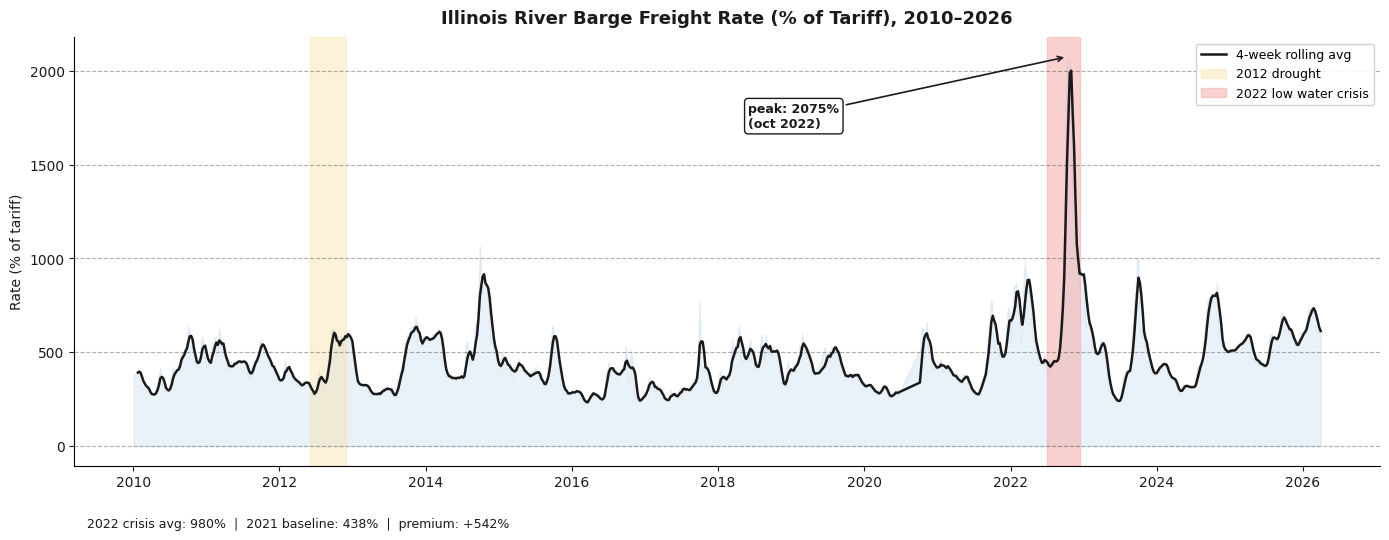

In [12]:
# fig 1: illinois river rate time series 2010–2026
fig, ax = plt.subplots(figsize=(14, 5.5))
roll = mergedDf.set_index('weekStart')['illRate'].rolling(4).mean()

# all data in pastel blue; crisis period highlighted in pastel red
ax.fill_between(mergedDf['weekStart'], mergedDf['illRate'], alpha=0.25, color=PBLUE)
ax.plot(roll.index, roll.values, color=BLACK, linewidth=1.8, label='4-week rolling avg')

# shade disruption bands
ax.axvspan(pd.Timestamp('2012-06-01'), pd.Timestamp('2012-12-01'), alpha=0.4, color=PYELLOW, label='2012 drought')
ax.axvspan(pd.Timestamp('2022-07-01'), pd.Timestamp('2022-12-15'), alpha=0.5, color=PRED,    label='2022 low water crisis')

ax.annotate(
    f'peak: {mergedDf["illRate"].max():.0f}%\n(oct 2022)',
    xy=(mergedDf.loc[mergedDf['illRate'].idxmax(), 'weekStart'], mergedDf['illRate'].max()),
    xytext=(pd.Timestamp('2018-06-01'), 1700),
    arrowprops=dict(arrowstyle='->', color=BLACK, lw=1.2),
    fontsize=9, color=BLACK, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', fc=WHITE, ec=BLACK)
)
ax.set_title('Illinois River Barge Freight Rate (% of Tariff), 2010–2026', fontsize=13, fontweight='bold', color=BLACK, pad=10)
ax.set_ylabel('Rate (% of tariff)', fontsize=10, color=BLACK)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.grid(axis='y', alpha=0.35, linestyle='--', color=BLACK)
ax.legend(fontsize=9, framealpha=0.9)
ax.text(0.01, -0.12,
    f'2022 crisis avg: {crisis22["illRate"].mean():.0f}%  |  2021 baseline: {baseline21["illRate"].mean():.0f}%  |  premium: +{crisis22["illRate"].mean()-baseline21["illRate"].mean():.0f}%',
    transform=ax.transAxes, va='top', fontsize=9, color=BLACK)
plt.tight_layout()
plt.savefig(figDir / 'fig1_rate_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


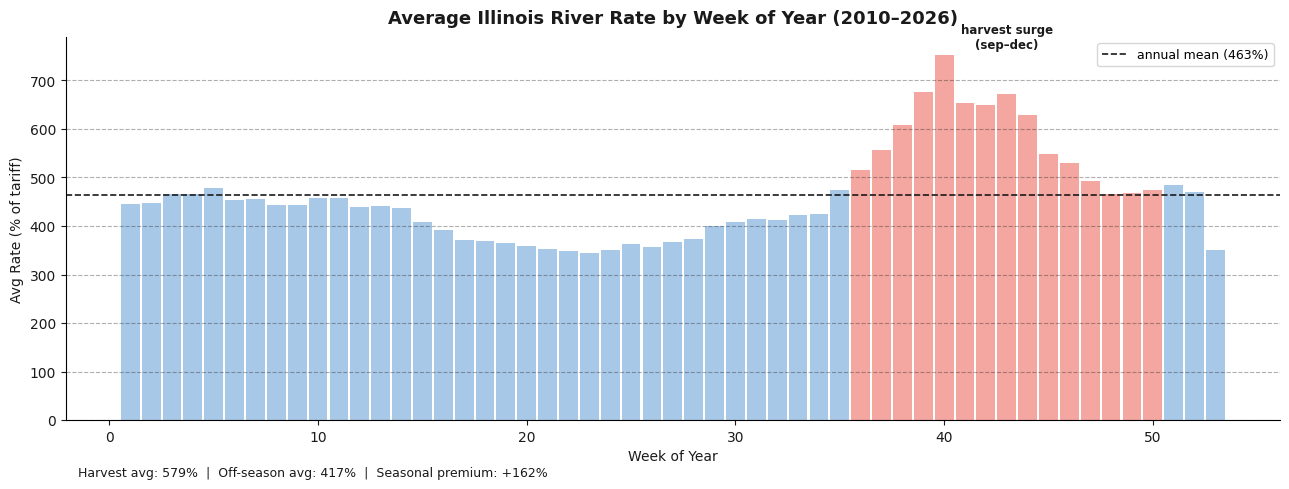

In [13]:
# fig 2: seasonal rate pattern by week of year
fig, ax = plt.subplots(figsize=(13, 5))
seasonal = mergedDf.groupby('week')['illRate'].mean()

# harvest weeks highlighted in pastel red, rest in pastel blue
barColors = [PRED if 36 <= w <= 50 else PBLUE for w in seasonal.index]
ax.bar(seasonal.index, seasonal.values, color=barColors, width=0.9, edgecolor='none')
ax.axhline(mergedDf['illRate'].mean(), color=BLACK, linestyle='--', linewidth=1.2,
           label=f'annual mean ({mergedDf["illRate"].mean():.0f}%)')
ax.text(43, seasonal.loc[36:50].max() + 15, 'harvest surge\n(sep–dec)',
        ha='center', fontsize=8.5, color=BLACK, fontweight='bold')
ax.set_title('Average Illinois River Rate by Week of Year (2010–2026)', fontsize=13, fontweight='bold', color=BLACK, pad=10)
ax.set_xlabel('Week of Year', fontsize=10)
ax.set_ylabel('Avg Rate (% of tariff)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.35, linestyle='--', color=BLACK)
ax.text(0.01, -0.12,
    f'Harvest avg: {harvestAvg:.0f}%  |  Off-season avg: {offseasonAvg:.0f}%  |  Seasonal premium: +{harvestAvg-offseasonAvg:.0f}%',
    transform=ax.transAxes, va='top', fontsize=9, color=BLACK)
plt.tight_layout()
plt.savefig(figDir / 'fig2_seasonal_pattern.png', dpi=150, bbox_inches='tight')
plt.show()


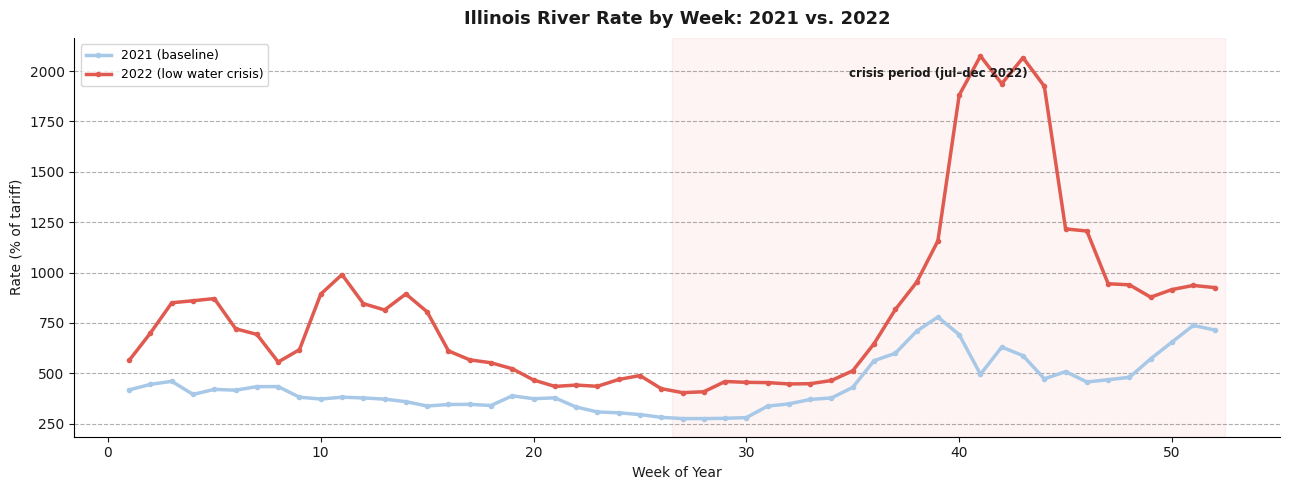

In [14]:
# fig 3: 2021 vs 2022 rate by week (crisis comparison)
fig, ax = plt.subplots(figsize=(13, 5))
yr21 = mergedDf[mergedDf['year'] == 2021].sort_values('week')
yr22 = mergedDf[mergedDf['year'] == 2022].sort_values('week')

ax.plot(yr21['week'], yr21['illRate'], color=PBLUE,  linewidth=2.5, marker='o', markersize=3, label='2021 (baseline)')
ax.plot(yr22['week'], yr22['illRate'], color='#e05a50', linewidth=2.5, marker='o', markersize=3, label='2022 (low water crisis)')
ax.axvspan(26.5, 52.5, alpha=0.12, color=PRED)
ax.text(39, yr22['illRate'].max() * 0.95, 'crisis period (jul–dec 2022)',
        ha='center', fontsize=8.5, color=BLACK, fontweight='bold')
ax.set_title('Illinois River Rate by Week: 2021 vs. 2022', fontsize=13, fontweight='bold', color=BLACK, pad=10)
ax.set_xlabel('Week of Year', fontsize=10)
ax.set_ylabel('Rate (% of tariff)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.35, linestyle='--', color=BLACK)
plt.tight_layout()
plt.savefig(figDir / 'fig3_2021v2022.png', dpi=150, bbox_inches='tight')
plt.show()


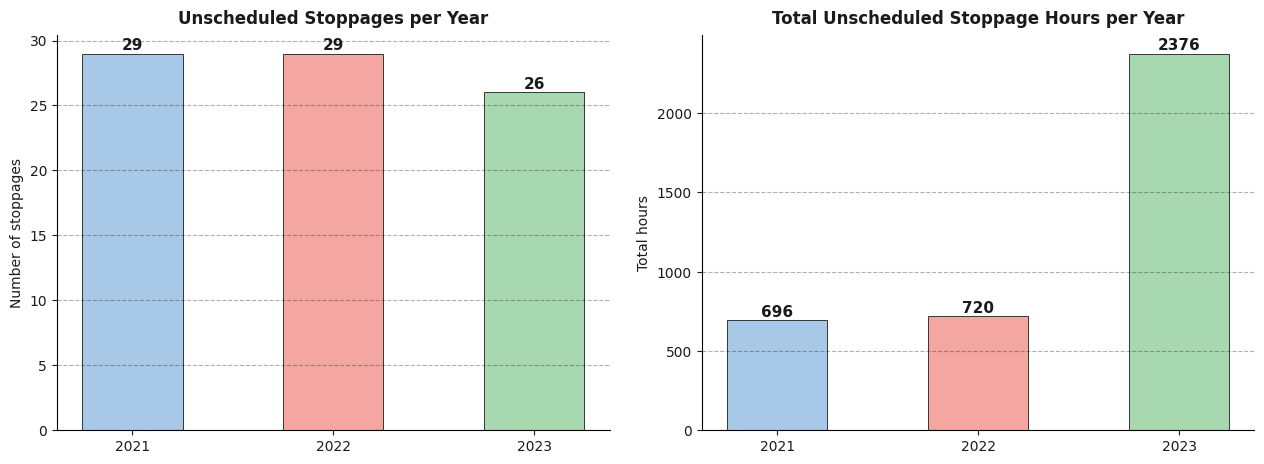

In [15]:
# fig 4: stoppages by year — count and hours side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
yrStats = unschedDf.groupby('year').agg(
    stoppages=('durationHrs', 'count'),
    totalHrs=('durationHrs', 'sum')
).reset_index()

yearColors = [PBLUE, PRED, PGREEN]  # 2021, 2022, 2023

for ax, col, title, ylabel in zip(
    axes,
    ['stoppages', 'totalHrs'],
    ['Unscheduled Stoppages per Year', 'Total Unscheduled Stoppage Hours per Year'],
    ['Number of stoppages', 'Total hours']
):
    bars = ax.bar(yrStats['year'].astype(str), yrStats[col], color=yearColors, width=0.5, edgecolor=BLACK, linewidth=0.6)
    for bar, (_, row) in zip(bars, yrStats.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(yrStats[col])*0.01,
                f'{row[col]:.0f}', ha='center', fontsize=11, fontweight='bold', color=BLACK)
    ax.set_title(title, fontsize=12, fontweight='bold', color=BLACK, pad=8)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(axis='y', alpha=0.35, linestyle='--', color=BLACK)

plt.tight_layout(pad=2)
plt.savefig(figDir / 'fig4_stoppages_by_year.png', dpi=150, bbox_inches='tight')
plt.show()


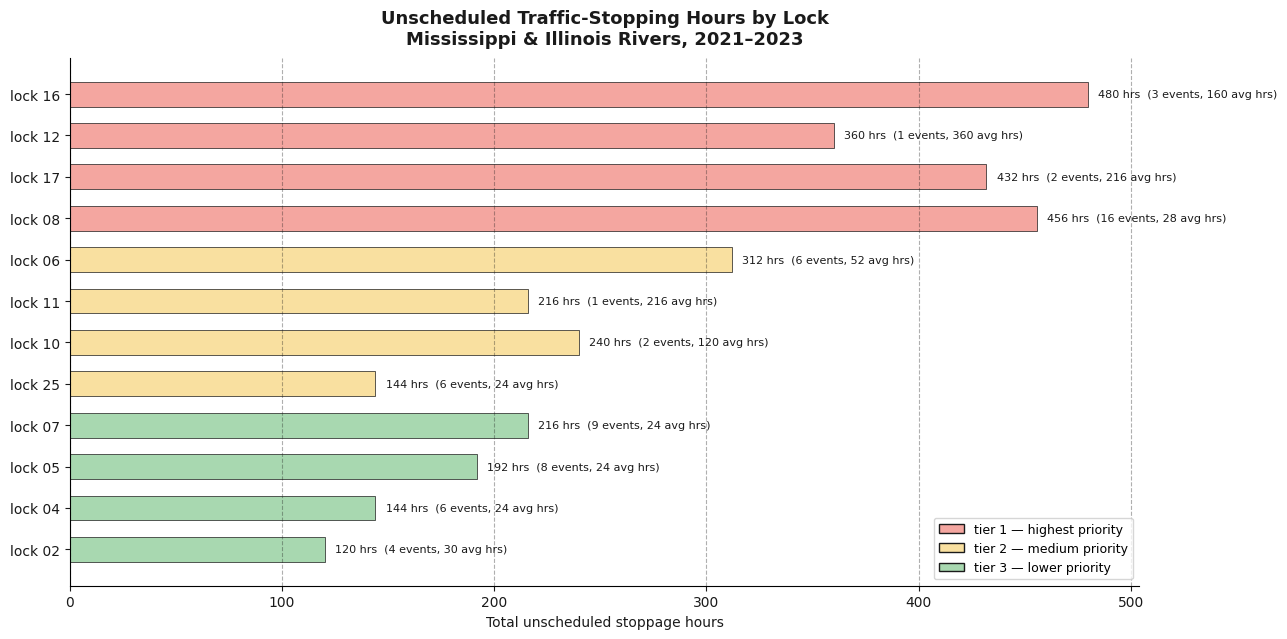

In [16]:
# fig 5: per-lock stoppage hours (top 12, tiered by priority rank)
fig, ax = plt.subplots(figsize=(13, 6.5))
top12 = lockSummary.head(12).iloc[::-1]

# tier colors: pastel red = highest priority, yellow = mid, green = lower
def tierColor(rank):
    if rank <= 4: return PRED
    if rank <= 8: return PYELLOW
    return PGREEN

barColors = [tierColor(r) for r in top12['priorityRank'].iloc[::-1]][::-1]
bars = ax.barh(top12['lockLabel'], top12['totalHrs'], color=barColors, height=0.6, edgecolor=BLACK, linewidth=0.5)

for bar, (_, row) in zip(bars, top12.iterrows()):
    ax.text(bar.get_width() + max(top12['totalHrs'])*0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{row["totalHrs"]:.0f} hrs  ({row["numStoppages"]} events, {row["avgHrs"]:.0f} avg hrs)',
            va='center', fontsize=8, color=BLACK)

ax.set_title('Unscheduled Traffic-Stopping Hours by Lock\nMississippi & Illinois Rivers, 2021–2023', fontsize=13, fontweight='bold', color=BLACK, pad=10)
ax.set_xlabel('Total unscheduled stoppage hours', fontsize=10)
ax.grid(axis='x', alpha=0.35, linestyle='--', color=BLACK)
ax.legend(handles=[
    mpatches.Patch(facecolor=PRED,    edgecolor=BLACK, label='tier 1 — highest priority'),
    mpatches.Patch(facecolor=PYELLOW, edgecolor=BLACK, label='tier 2 — medium priority'),
    mpatches.Patch(facecolor=PGREEN,  edgecolor=BLACK, label='tier 3 — lower priority'),
], fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(figDir / 'fig5_lock_stoppage_hours.png', dpi=150, bbox_inches='tight')
plt.show()


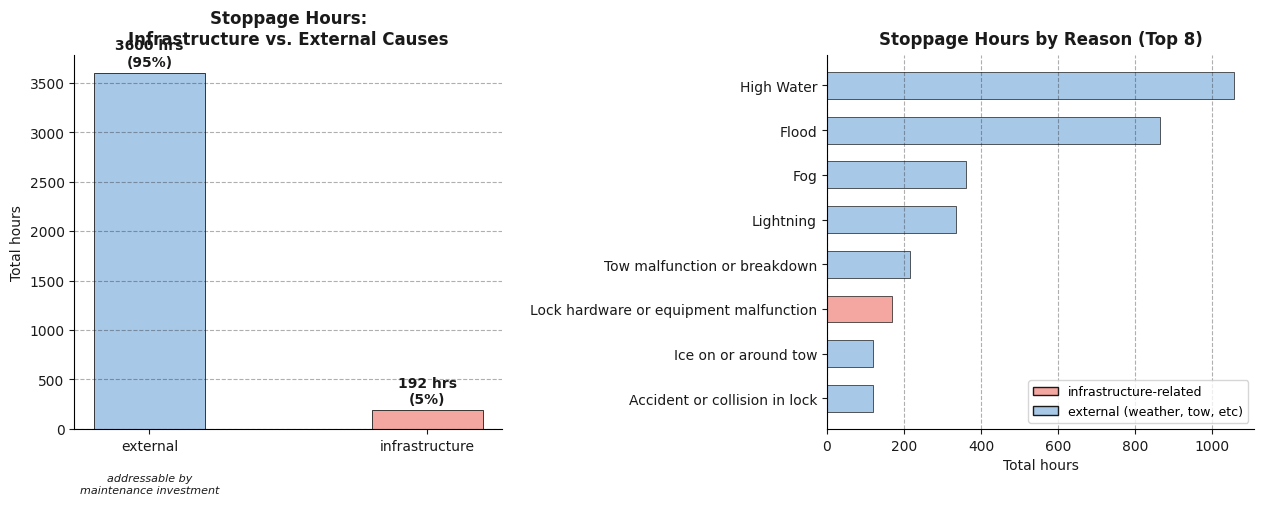

In [17]:
# fig 6: stoppage cause breakdown
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# infra vs external — pastel red = addressable by maintenance
ax = axes[0]
causeHrs = unschedDf.groupby('causeType')['durationHrs'].sum()
causeColors = [PRED if 'infra' in idx else PBLUE for idx in causeHrs.index]
bars = ax.bar(causeHrs.index, causeHrs.values, color=causeColors, width=0.4, edgecolor=BLACK, linewidth=0.6)
for bar, (idx, val) in zip(bars, causeHrs.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(causeHrs)*0.02,
            f'{val:.0f} hrs\n({val/causeHrs.sum()*100:.0f}%)',
            ha='center', fontsize=10, fontweight='bold', color=BLACK)
ax.set_title('Stoppage Hours:\nInfrastructure vs. External Causes', fontsize=12, fontweight='bold', color=BLACK, pad=8)
ax.set_ylabel('Total hours', fontsize=10)
ax.grid(axis='y', alpha=0.35, linestyle='--', color=BLACK)
ax.text(0, -max(causeHrs)*0.18, 'addressable by\nmaintenance investment', ha='center', fontsize=8, color=BLACK, style='italic')

# top reason codes — red = infra, blue = external
ax = axes[1]
reasonHrs = unschedDf.groupby('reasonCode')['durationHrs'].sum().sort_values(ascending=True).tail(8)
reasonHrs.index = [r[:38] + '…' if len(r) > 38 else r for r in reasonHrs.index]
reasonColors = [PRED if any(k in r.lower() for k in ['repair', 'hardware', 'maintain']) else PBLUE
                for r in reasonHrs.index]
ax.barh(reasonHrs.index, reasonHrs.values, color=reasonColors, height=0.6, edgecolor=BLACK, linewidth=0.5)
ax.set_title('Stoppage Hours by Reason (Top 8)', fontsize=12, fontweight='bold', color=BLACK, pad=8)
ax.set_xlabel('Total hours', fontsize=10)
ax.grid(axis='x', alpha=0.35, linestyle='--', color=BLACK)
ax.legend(handles=[
    mpatches.Patch(facecolor=PRED,  edgecolor=BLACK, label='infrastructure-related'),
    mpatches.Patch(facecolor=PBLUE, edgecolor=BLACK, label='external (weather, tow, etc)'),
], fontsize=9)

plt.tight_layout(pad=2)
plt.savefig(figDir / 'fig6_stoppage_causes.png', dpi=150, bbox_inches='tight')
plt.show()


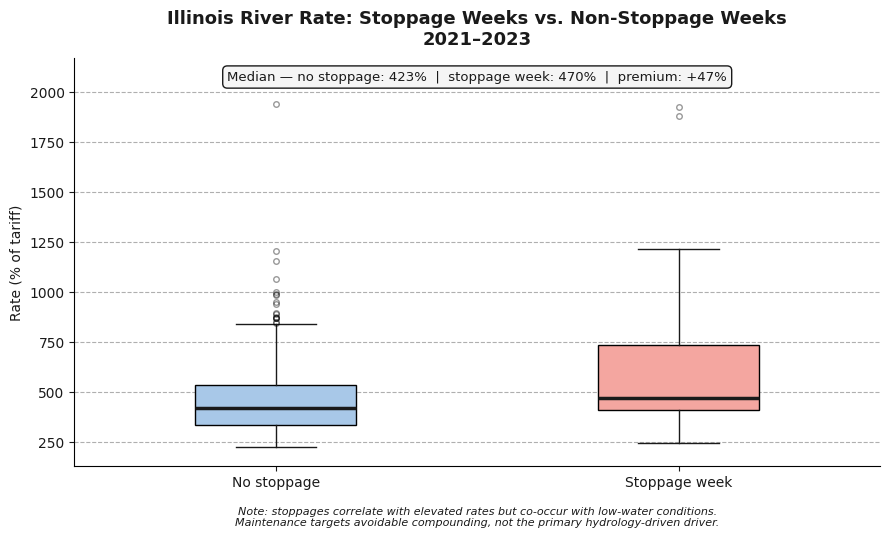

In [18]:
# fig 7: rate distribution — stoppage vs non-stoppage weeks
fig, ax = plt.subplots(figsize=(9, 5.5))
bp = ax.boxplot(
    [noStopWeekRates.values, stopWeekRates.values],
    labels=['No stoppage', 'Stoppage week'],
    patch_artist=True, widths=0.4,
    medianprops=dict(color=BLACK, linewidth=2.5)
)
bp['boxes'][0].set_facecolor(PBLUE)
bp['boxes'][1].set_facecolor(PRED)
for el in ['whiskers', 'caps']:
    for item in bp[el]:
        item.set_color(BLACK)
for flier in bp['fliers']:
    flier.set(marker='o', color=BLACK, alpha=0.4, markersize=4)

ax.set_title('Illinois River Rate: Stoppage Weeks vs. Non-Stoppage Weeks\n2021–2023', fontsize=13, fontweight='bold', color=BLACK, pad=10)
ax.set_ylabel('Rate (% of tariff)', fontsize=10)
ax.grid(axis='y', alpha=0.35, linestyle='--', color=BLACK)
ax.text(0.5, 0.97,
    f'Median — no stoppage: {noStopWeekRates.median():.0f}%  |  stoppage week: {stopWeekRates.median():.0f}%  |  premium: +{stopWeekRates.median()-noStopWeekRates.median():.0f}%',
    transform=ax.transAxes, ha='center', va='top', fontsize=9.5, color=BLACK,
    bbox=dict(boxstyle='round,pad=0.35', fc='#f5f5f5', ec=BLACK))
ax.text(0.5, -0.1,
    'Note: stoppages correlate with elevated rates but co-occur with low-water conditions.\n'
    'Maintenance targets avoidable compounding, not the primary hydrology-driven driver.',
    transform=ax.transAxes, ha='center', va='top', fontsize=8, color=BLACK, style='italic')
plt.tight_layout()
plt.savefig(figDir / 'fig7_rate_stoppage_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


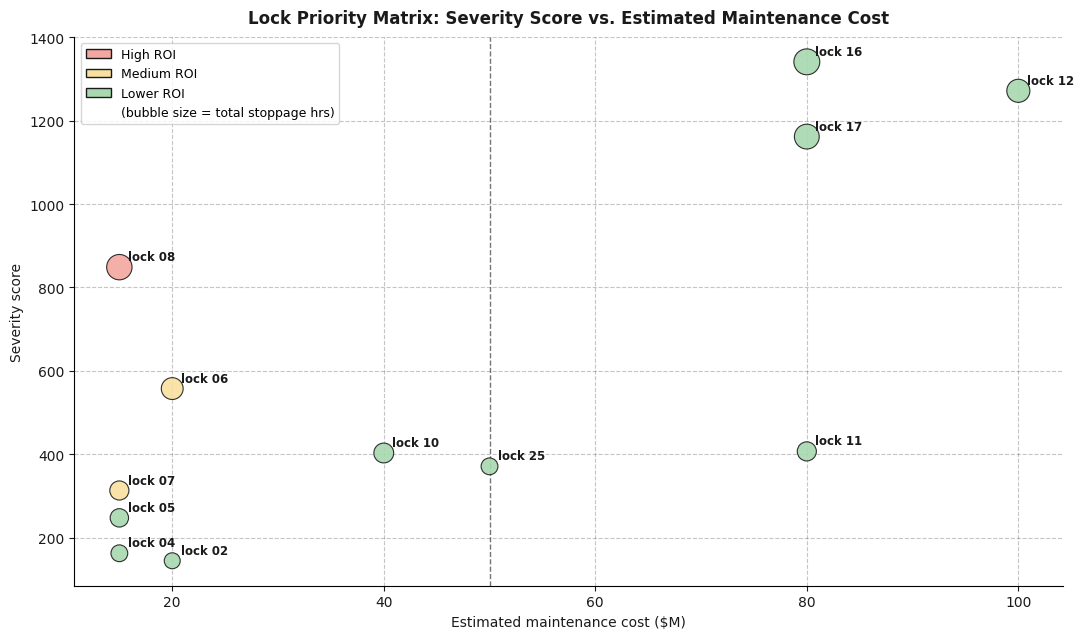

In [19]:
# fig 8: priority matrix — severity vs estimated cost
fig, ax = plt.subplots(figsize=(11, 6.5))
top = lockSummary.head(12)

# color by roi tier: red = best roi, yellow = mid, green = lower
roiMax, roiMin = top['roi'].max(), top['roi'].min()
def roiColor(roi):
    norm = (roi - roiMin) / (roiMax - roiMin + 1e-9)
    if norm > 0.6: return PRED
    if norm > 0.3: return PYELLOW
    return PGREEN

ptColors = [roiColor(r) for r in top['roi']]
scatter = ax.scatter(
    top['estCostM'], top['severityScore'],
    s=top['totalHrs'] * 0.6 + 60,
    c=ptColors,
    edgecolors=BLACK, linewidths=0.8, alpha=0.9, zorder=3
)

for _, row in top.iterrows():
    ax.annotate(row['lockLabel'],
                xy=(row['estCostM'], row['severityScore']),
                xytext=(6, 5), textcoords='offset points',
                fontsize=8.5, color=BLACK, fontweight='bold')

ax.axvline(x=50, color=BLACK, linestyle='--', linewidth=1, alpha=0.6, label='$50M budget line')
ax.set_title('Lock Priority Matrix: Severity Score vs. Estimated Maintenance Cost', fontsize=12, fontweight='bold', color=BLACK, pad=10)
ax.set_xlabel('Estimated maintenance cost ($M)', fontsize=10)
ax.set_ylabel('Severity score', fontsize=10)
ax.grid(alpha=0.25, linestyle='--', color=BLACK)
ax.legend(handles=[
    mpatches.Patch(facecolor=PRED,    edgecolor=BLACK, label='High ROI'),
    mpatches.Patch(facecolor=PYELLOW, edgecolor=BLACK, label='Medium ROI'),
    mpatches.Patch(facecolor=PGREEN,  edgecolor=BLACK, label='Lower ROI'),
    mpatches.Patch(facecolor='none',  edgecolor='none', label='(bubble size = total stoppage hrs)'),
], fontsize=9)
plt.tight_layout()
plt.savefig(figDir / 'fig8_priority_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


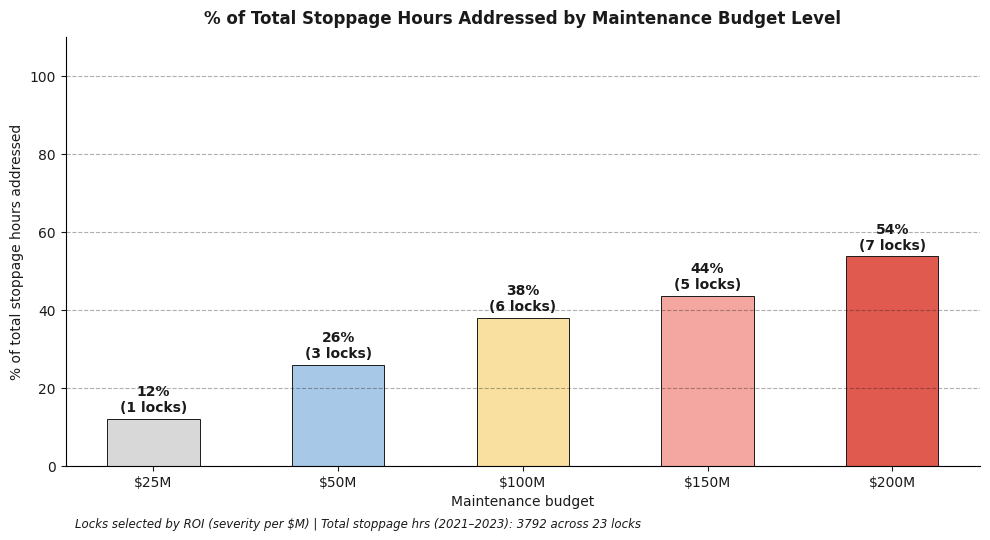

In [20]:
# fig 9: budget scenario comparison
fig, ax = plt.subplots(figsize=(10, 5.5))
totalHrs = lockSummary['totalHrs'].sum()
budgetLabels, pcts, countLabels = [], [], []
roiSorted = lockSummary.sort_values('roi', ascending=False)

for budgetM in [25, 50, 100, 150, 200]:
    selected, spent = [], 0
    for _, row in roiSorted.iterrows():
        if spent + row['estCostM'] <= budgetM:
            selected.append(row['lockLabel'])
            spent += row['estCostM']
    hrsAddressed = roiSorted[roiSorted['lockLabel'].isin(selected)]['totalHrs'].sum()
    pct = hrsAddressed / totalHrs * 100
    budgetLabels.append(f'${budgetM}M')
    pcts.append(pct)
    countLabels.append(f'{pct:.0f}%\n({len(selected)} locks)')

# gradient from light to dark pastel red as budget grows
budgetColors = [PGRAY, PBLUE, PYELLOW, PRED, '#e05a50']
bars = ax.bar(budgetLabels, pcts, color=budgetColors, width=0.5, edgecolor=BLACK, linewidth=0.7)
for bar, label in zip(bars, countLabels):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            label, ha='center', va='bottom', fontsize=10, fontweight='bold', color=BLACK)

ax.set_title('% of Total Stoppage Hours Addressed by Maintenance Budget Level', fontsize=12, fontweight='bold', color=BLACK, pad=10)
ax.set_xlabel('Maintenance budget', fontsize=10)
ax.set_ylabel('% of total stoppage hours addressed', fontsize=10)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.35, linestyle='--', color=BLACK)
ax.text(0.01, -0.12,
    f'Locks selected by ROI (severity per $M) | Total stoppage hrs (2021–2023): {totalHrs:.0f} across {len(lockSummary)} locks',
    transform=ax.transAxes, va='top', fontsize=8.5, color=BLACK, style='italic')
plt.tight_layout()
plt.savefig(figDir / 'fig9_budget_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. export results

In [21]:
lockSummary.to_csv(projectDir / 'lock_priority_ranking.csv', index=False)
analysisDf.to_csv(projectDir / 'merged_weekly_data.csv', index=False)

print('outputs saved:')
print('  lock_priority_ranking.csv')
print('  merged_weekly_data.csv')
print(f'  figures/ (9 charts — fig1 through fig9)')

outputs saved:
  lock_priority_ranking.csv
  merged_weekly_data.csv
  figures/ (9 charts — fig1 through fig9)
